In [1]:
import numpy as np
from numba import vectorize, guvectorize, float64, int64
from scipy.special import comb
import matplotlib.pyplot as plt
import time

#make plots look pretty 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    #"axes.linewidth": 2,
    #"xtick.labelsize": 16,
    #"ytick.labelsize": 16,
    #"axes.labelsize": 16,
    #"axes.titlesize": 20,
    #"legend.fontsize": 16,
    #"legend.edgecolor": 'white'
})

#define variables
target = 'METHINKS IT IS LIKE A WEASEL'
alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ '
N_offspring = 100
mut_rate = 0.05
N_trials = 10000
L = len(target)
p, q = 1-mut_rate/len(alphabet), mut_rate*(1-1/len(alphabet))

#represent letters as numbers so we can use simple numpy arrays instead of character lists
alphabet_dict = {alphabet[i]: i for i in range(len(alphabet))}
#reversed version of the previous, useful only if we want to print intermediate simulation results
alphabet_dict_rev = {i: alphabet[i] for i in range(len(alphabet))}
#turn the target string into an array of numbers
target = np.array([alphabet_dict[target[i]] for i in range(len(target))])

#simulation, generating random 'offspring', mutating them, and keeping only the one closest to the target
#until after some number of steps all the characters of the best offspring become the same as the target.
#vectorize the function with numba to make it faster
#in order to print intermediate results, change N_trials to 1, comment out the guvectorize line (44)
#and ".astype(float64)" in line 48,
#and uncomment the print statement and the lines defining and returning the result array "res" (46 and 65)
@guvectorize([(int64[:], int64, float64, int64[:], int64[:])], '(n),(),(),(p)->(p)', target='parallel', nopython=True)
def loop(target, N_offspring, mut_rate, trials, res):
    #res = np.zeros_like(trials)
    for k in trials:
        a = np.random.choice(len(alphabet), len(target)).astype(float64)
        count = 0
        max_distance = len(target)
        while np.sum(a!=target) > 0:
            offspring = np.zeros((N_offspring, len(a)))
            offspring[:]=a
            random = np.random.random(size=(offspring.shape[0], offspring.shape[1]))
            mutations = np.random.choice(len(alphabet), size=(offspring.shape[0], offspring.shape[1]))
            mutated = np.where(random < mut_rate*np.ones_like(random), mutations, offspring)
            distance = np.sum(mutated[:]!=target, axis=1)
            best_dist = np.min(distance)
            if best_dist <= max_distance:
                max_distance = best_dist
                a = mutated[np.argmin(distance)]
                count += 1
                #print("".join([alphabet_dict_rev[i] for i in a]))
        res[k]=count
    #return res

#call the function we just defined and time the run
trials = np.arange(N_trials)
empty1 = np.empty_like(trials)
start = time.time()
dist = loop(target, N_offspring, mut_rate, trials, empty1)
end = time.time()
print(str(end-start) + " sec")

152.85701489448547 sec


In [2]:
#find the (simulated) mean number of steps as a function of mutation rate, store it, and time it, 10 trials each point 
mean_range_mut = np.linspace(1e-5, .1)
means_simulated_mut = []
N_trials2 = 10
start2 = time.time()
for i in mean_range_mut:
    mean_dist = np.mean(loop(target, N_offspring, i, np.arange(N_trials2), np.empty_like(np.arange(N_trials2))))
    means_simulated_mut.append(mean_dist)

end2 = time.time()
print(str(end2-start2)+ " sec")

199.80583453178406 sec


Text(0, 0.5, 'time to completion (steps)')

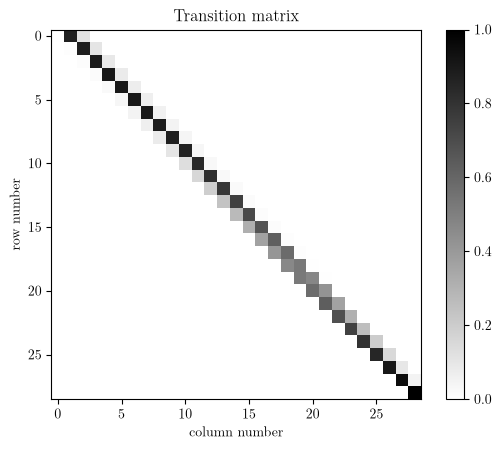

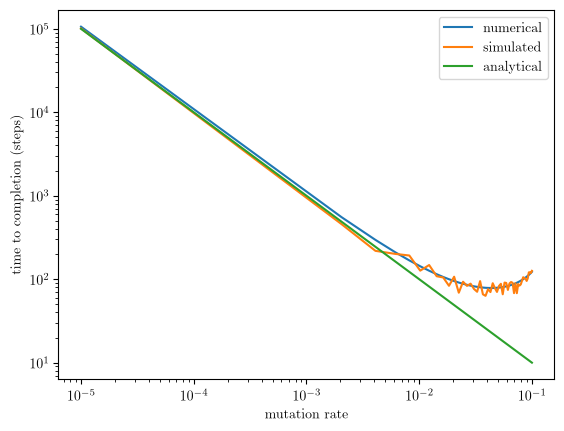

In [3]:
#transition matrix for n mutating characters, to model the process
@vectorize([float64(float64, float64, float64, float64, float64)], forceobj=True)
def transition(n,j,k,p,q):
    i = np.arange(n+1)
    return np.sum(comb(n-j, k-j+i)*(1-p)**(k-j+i)*(p)**(n-k-i)*comb(j,i)*q**i*(1-q)**(j-i))

#create the full transition matrix for the maximum of n characters and look at it 
def transitionfull(L, N_offspring, mut_rate, len_alphabet):
    a = np.arange(L+1)
    p, q = 1-mut_rate/len_alphabet, mut_rate*(1-1/len_alphabet)
    A = transition(L,a[:,None],a,p,q) 
    B = np.cumsum(A, axis=1)**N_offspring 
    C = np.roll(B,1)
    C[:,0]=0
    D = B-C
    D[L]=0
    D[L,L]=1
    return D

D = transitionfull(L, N_offspring, mut_rate, len(alphabet))
plt.figure(2)
plt.imshow(D, cmap='binary')
plt.xlabel("column number")
plt.ylabel("row number")
plt.title("Transition matrix")
plt.colorbar()

#initial distribution
def F(L):
    F = np.zeros(L)
    F[0]=1
    return F

#calculate the predicted distribution, both cdf and pdf
#able to capture the vast majority of the distribution's mass in an interval of length 4*int(mean) (steps)
mean = int(F(L)@np.linalg.solve(np.eye(L)-D[0:L,0:L], np.ones(L)))
pdf = np.array([F(L)@np.linalg.matrix_power(D[0:L,0:L],j)@((np.eye(L)-D[0:L,0:L])@np.ones(L)) for j in range(4*mean)])
cdf = np.array([1-F(L)@np.linalg.matrix_power(D[0:L,0:L],j)@np.ones(L) for j in range(1,4*mean)])

#calculate the predicted mean number of steps as a function of mutation rate
means_calculated_mut = []
for k in mean_range_mut:
    A = transitionfull(L, N_offspring, k, len(alphabet))
    mean_calc = F(L)@np.linalg.solve(np.eye(L)-A[0:L,0:L], np.ones(L))
    means_calculated_mut.append(mean_calc)

plt.figure(3)
plt.loglog(mean_range_mut, means_calculated_mut, label='numerical')
plt.loglog(mean_range_mut, means_simulated_mut, label='simulated')
plt.loglog(mean_range_mut, 1/mean_range_mut, label='analytical')
plt.legend()
plt.xlabel("mutation rate")
plt.ylabel("time to completion (steps)")

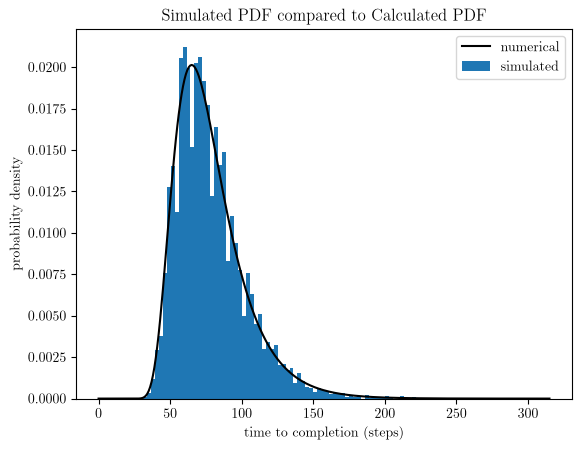

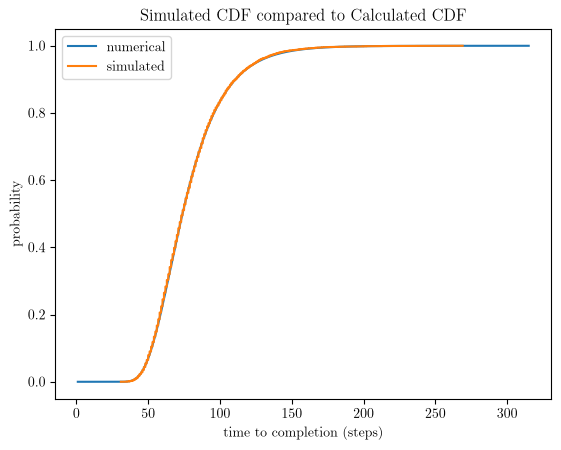

In [4]:
plt.figure(4)
plt.plot(np.arange(4*mean), pdf, label='numerical', color='black')
k, bins, patches = plt.hist(dist, density=True, bins='auto', label='simulated')
plt.xlabel("time to completion (steps)")
plt.ylabel("probability density")
plt.title("Simulated PDF compared to Calculated PDF")
plt.legend()

plt.figure(5)
plt.plot(np.arange(1,4*mean), cdf, label='numerical')
#lines 12 and 13 are two different ways of plotting the cumulative distribution, giving very similar results
plt.step(np.sort(dist), np.arange(len(dist))/(len(dist)-1), where='mid', label='simulated')
#plt.hist(dist, density=True, cumulative=True, bins='auto', label='simulation', histtype='step')
plt.xlabel("time to completion (steps)")
plt.ylabel("probability")
plt.title("Simulated CDF compared to Calculated CDF")
plt.legend()